# House Price Prediction Using Machine Learning

### Internship Project – Week 1

**Name:** Riya Jha  
**Dataset:** Housing Prices Dataset  
**Objective:** Predict house prices using machine learning models and identify the key factors influencing property value.

# Executive Summary

The real estate market relies heavily on accurate property valuation to support buying, selling, and investment decisions. In this project, machine learning techniques were applied to develop a predictive model capable of estimating residential house prices based on property characteristics.

A housing dataset containing 545 residential properties was analyzed, cleaned, and transformed into a machine-learning-ready format. Exploratory Data Analysis (EDA) was performed to understand the distribution of prices and identify relationships between property features.

Two machine learning algorithms were evaluated: Linear Regression and Random Forest Regressor. Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The results showed that Linear Regression achieved the strongest predictive performance with an R² Score of 0.6529, outperforming the more complex Random Forest model. Feature importance analysis revealed that property area was the most significant determinant of house value, accounting for nearly half of the model's predictive capability.

The findings demonstrate that property size, number of bathrooms, air conditioning availability, parking capacity, and number of stories are the primary drivers of residential property prices. These insights can assist real estate businesses in property valuation, marketing strategy, and investment decision-making.


## Project Workflow

1. Data Loading and Exploration
2. Data Quality Assessment
3. Data Preprocessing and Feature Engineering
4. Exploratory Data Analysis
5. Model Development
6. Model Evaluation
7. Feature Importance Analysis
8. Business Insights and Recommendations
9. Conclusion

In [148]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries loaded successfully.")

All libraries loaded successfully.


# 1. Data Loading and Exploration

In this section, the housing dataset is loaded and inspected to understand its structure, dimensions, and overall quality before any preprocessing or modeling is performed.

In [149]:
# Load dataset

df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [150]:
# Display first 10 rows

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [151]:
# Dataset dimensions

rows, columns = df.shape

print(f"Number of Rows: {rows}")
print(f"Number of Columns: {columns}")

Number of Rows: 545
Number of Columns: 13


In [152]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [153]:
# Check for missing values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [154]:
# Check for duplicate rows

df.duplicated().sum()

np.int64(0)

### Initial Observations

- The dataset contains 545 residential properties and 13 attributes.
- The target variable for prediction is **price**.
- No missing values were detected in the dataset.
- No duplicate records were found.
- The dataset contains both numerical and categorical features.
- Categorical variables will require encoding before model training.

# 2. Data Preprocessing and Feature Engineering

Before training machine learning models, categorical variables must be converted into a numerical format. This ensures that the algorithms can correctly interpret all features within the dataset.

In [155]:
# Convert categorical variables into numerical format

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [156]:
print("Original Dataset Shape:", df.shape)
print("Encoded Dataset Shape:", df_encoded.shape)

Original Dataset Shape: (545, 13)
Encoded Dataset Shape: (545, 14)


### Feature Engineering Summary

The dataset originally contained several categorical variables such as:

- mainroad
- guestroom
- basement
- hotwaterheating
- airconditioning
- prefarea
- furnishingstatus

These variables were transformed into numerical representations using one-hot encoding. This preprocessing step ensures compatibility with machine learning algorithms while preserving the information contained within the original categories.

# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns, relationships, and trends within the housing dataset. The following visualizations provide insights into price distribution and the factors influencing property value.

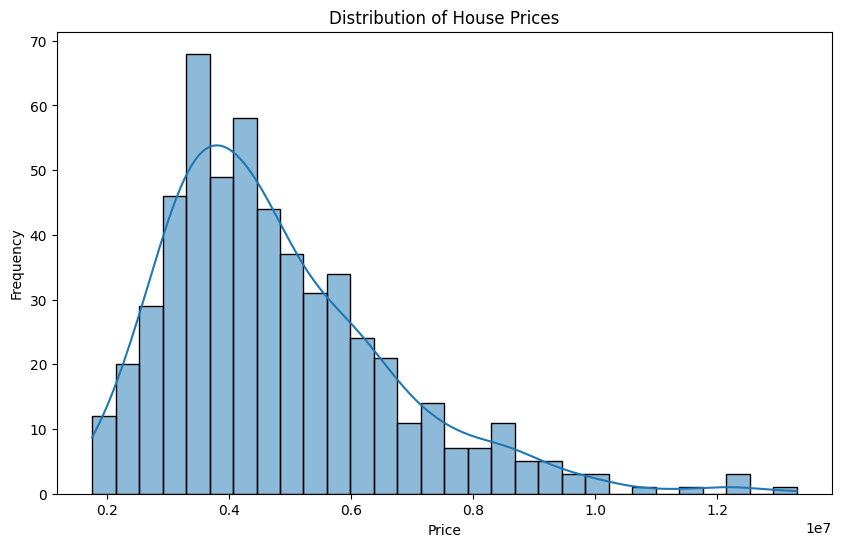

In [157]:
# House Price Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")

plt.show()

### Correlation Analysis

Correlation analysis helps identify which numerical variables have the strongest relationship with house price. Strong positive correlations indicate that as one variable increases, house prices tend to increase as well.

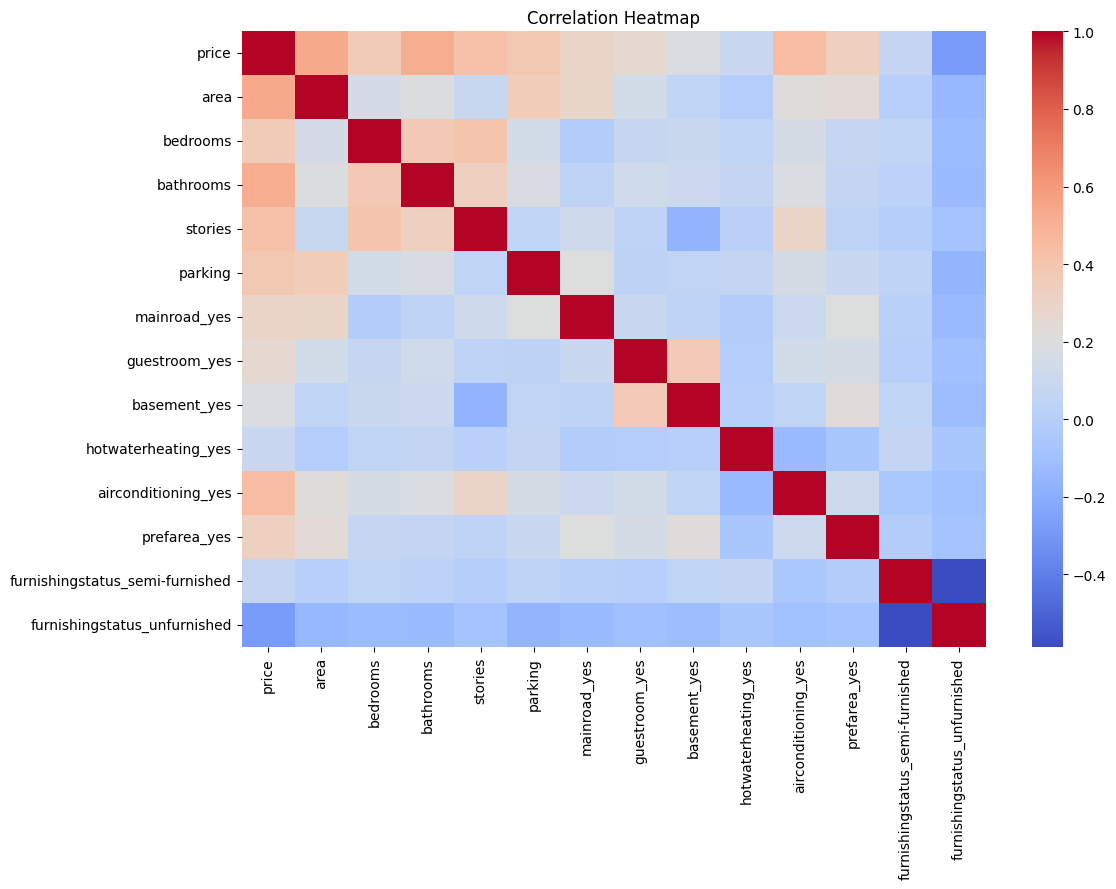

In [158]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

correlation_matrix = df_encoded.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

# 4. Model Development

The objective of this section is to train machine learning models capable of predicting house prices based on property characteristics.

Two models will be evaluated:

1. Linear Regression
2. Random Forest Regressor

The performance of both models will be compared using standard regression metrics.

In [159]:
# Define features and target

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]

print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

Feature Matrix Shape: (545, 13)
Target Vector Shape: (545,)


In [160]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 436
Testing Samples: 109


In [161]:
# Linear Regression Model

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [162]:
# Linear Regression Evaluation

lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("-" * 40)
print("MAE :", round(lr_mae, 2))
print("RMSE:", round(lr_rmse, 2))
print("R²  :", round(lr_r2, 4))

Linear Regression Results
----------------------------------------
MAE : 970043.4
RMSE: 1324506.96
R²  : 0.6529


## Random Forest Regressor

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [163]:
# Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [164]:
# Random Forest Evaluation

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("-" * 40)
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Results
----------------------------------------
MAE : 1013968.58
RMSE: 1398115.67
R²  : 0.6133


In [165]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


In [166]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [round(lr_mae,2), round(rf_mae,2)],
    "RMSE": [round(lr_rmse,2), round(rf_rmse,2)],
    "R² Score": [round(lr_r2,4), round(rf_r2,4)]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,970043.40,1324506.96,0.6529
1,Random Forest,1013968.58,1398115.67,0.6133


### Model Comparison Insights

The Linear Regression model outperformed the Random Forest Regressor across all evaluation metrics.

Key observations:

- Linear Regression achieved the highest R² score.
- Linear Regression produced lower prediction errors.
- The results suggest that house prices in this dataset exhibit strong linear relationships with the available features.
- A more complex ensemble model did not provide additional predictive benefits for this dataset.

Based on the evaluation metrics, Linear Regression was selected as the best-performing model.

## Actual vs Predicted Prices

The following visualization compares actual house prices against model predictions. A strong alignment between points and the diagonal trend indicates better predictive performance.

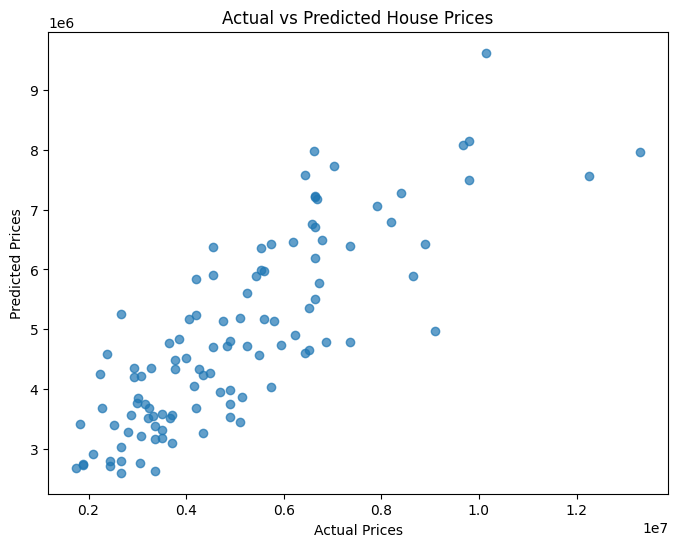

In [167]:
# Actual vs Predicted Prices

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_predictions,
    alpha=0.7
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

# 5. Feature Importance Analysis

Understanding which factors most strongly influence house prices is often more valuable than prediction alone.

This analysis uses the Random Forest model to identify the most important features affecting property value.

In [168]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,area,0.468535
2,bathrooms,0.152554
9,airconditioning_yes,0.060238
4,parking,0.057273
3,stories,0.057064
1,bedrooms,0.047370
12,furnishingstatus_unfurnished,0.036972
7,basement_yes,0.032176
10,prefarea_yes,0.028432
8,hotwaterheating_yes,0.018305


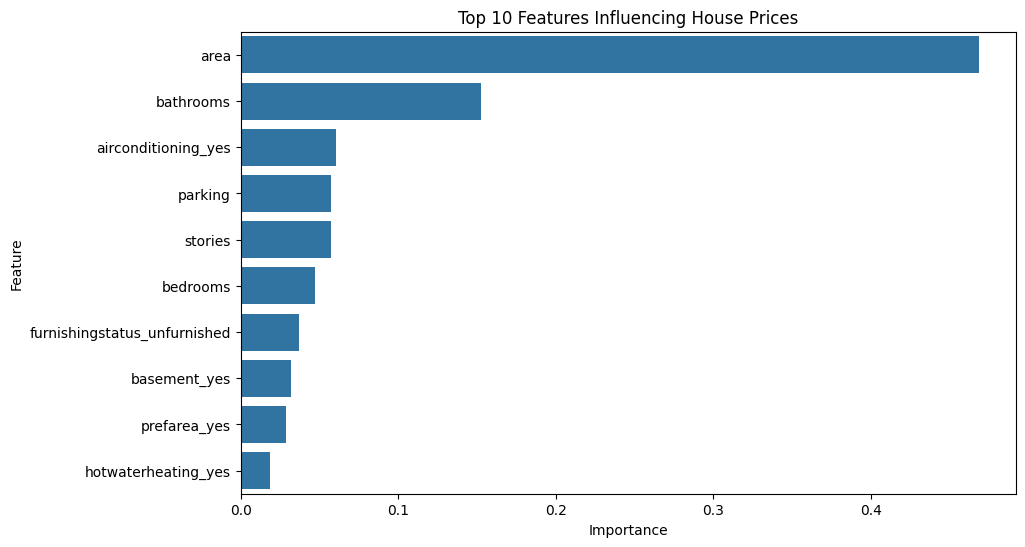

In [169]:
# Top 10 Feature Importance

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing House Prices")

plt.savefig("charts/feature_importance.png")

plt.show()

### Key Findings from Feature Importance Analysis

The analysis reveals that **property area** is by far the most influential factor affecting house prices, contributing nearly half of the model's predictive power.

Other important factors include:

- Number of bathrooms
- Availability of air conditioning
- Parking capacity
- Number of stories

These findings indicate that both property size and quality-of-life amenities play a major role in determining market value.

# 6. Insights and Business Recommendations

### Which features influence house price the most?

The most influential feature was property area, followed by bathrooms, air conditioning, parking availability, and the number of stories. These factors consistently contributed the most to price prediction.

### How accurate was the model?

The Linear Regression model achieved an R² score of approximately 0.65, meaning it explained around 65% of the variation in house prices. This indicates a reasonably strong predictive capability for a simple regression model.

### What was surprising?

A surprising finding was that the Linear Regression model outperformed the Random Forest model. This suggests that the relationships within this dataset are largely linear and can be captured effectively without a highly complex model.

### Recommendation for Real Estate Businesses

Real estate companies should prioritize highlighting property size, bathroom count, parking facilities, and air conditioning features in listings and marketing campaigns, as these attributes appear to have the strongest impact on property value.

# Conclusion

This project successfully developed and evaluated machine learning models for predicting residential house prices using real-world housing data.

The analysis included data exploration, preprocessing, feature engineering, visualization, model development, performance evaluation, and feature importance analysis. Among the evaluated algorithms, Linear Regression achieved the highest predictive performance with an R² Score of 0.6529.

The study found that property area is the dominant factor influencing house prices, followed by bathrooms, air conditioning, parking availability, and number of stories. These insights provide valuable guidance for buyers, sellers, and real estate professionals seeking to understand the factors that drive property valuation.

Overall, the project demonstrates how machine learning can support data-driven decision-making within the real estate industry while providing interpretable insights into the factors affecting residential property value.
